## 1. Setup and Imports

In [7]:
import os
import time
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.backends.cudnn as cudnn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from PIL import Image

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# ============================================================================
# EMBEDDED UTILITY CLASSES (No external imports needed)
# ============================================================================

class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


def accuracy(output, target, topk=(1,)):
    """Computes the precision@k for the specified values of k"""
    maxk = max(topk)
    batch_size = target.size(0)

    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))

    res = []
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum(0)
        res.append(correct_k.mul_(100.0 / batch_size))
    return res


class SelfAdaptiveTrainingBalanced():
    """
    Self-Adaptive Training (SAT) with Class-Balanced Loss Weighting
    
    Key Features:
    - UNIFORM high momentum (0.99) for ALL classes (STABLE)
    - Class-balanced weighting using Effective Number of Samples
    - Two-stage training: balanced CE (init) then SAT (fine-tune)
    """
    def __init__(self, num_examples=50000, num_classes=10, mom=0.99, 
                 class_sample_counts=None, beta=0.9999):
        self.prob_history = torch.zeros(num_examples, num_classes)
        self.updated = torch.zeros(num_examples, dtype=torch.int)
        self.mom = mom  # UNIFORM momentum for all classes
        self.num_classes = num_classes
        self.beta = beta
        
        # Calculate class weights using Effective Number of Samples
        if class_sample_counts is not None:
            class_sample_counts = np.array(class_sample_counts)
            
            # Effective number: (1 - β^n) / (1 - β)
            effective_num = 1.0 - np.power(beta, class_sample_counts)
            effective_num = np.where(effective_num > 0, effective_num, 1e-7)
            
            # Class weight: 1 / effective_num, normalized
            class_weights = (1.0 - beta) / effective_num
            class_weights = class_weights / (class_weights.sum() / num_classes)
            self.class_weights = torch.FloatTensor(class_weights)
            
            # Print configuration
            print(f"\n🔧 SAT with Class-Balanced Loss:")
            print(f"   Momentum: {mom} (UNIFORM - STABLE)")
            print(f"   Effective Number β: {beta}")
            print(f"   \n   Class Weights (Effective Number):")
            for i, (count, weight) in enumerate(zip(class_sample_counts, class_weights)):
                print(f"   Class {i}: {count:4d} samples → weight={weight:.4f}")
        else:
            self.class_weights = torch.ones(num_classes)

    def _update_prob(self, prob, index, y):
        """Update probability history with UNIFORM high momentum"""
        onehot = torch.zeros_like(prob)
        onehot[torch.arange(y.shape[0]), y] = 1
        prob_history = self.prob_history[index].clone().to(prob.device)

        # Initialize with onehot if not yet updated
        cond = (self.updated[index] == 1).to(prob.device).unsqueeze(-1).expand_as(prob)
        prob_mom = torch.where(cond, prob_history, onehot)

        # UNIFORM high momentum (same for all classes - STABLE)
        prob_mom = self.mom * prob_mom + (1 - self.mom) * prob

        self.updated[index] = 1
        self.prob_history[index] = prob_mom.to(self.prob_history.device)

        return prob_mom

    def __call__(self, logits, y, index, use_class_weights=True):
        """Calculate SAT loss with optional class weighting"""
        prob = F.softmax(logits.detach()[:, :self.num_classes], dim=1)
        prob = self._update_prob(prob, index, y)

        soft_label = torch.zeros_like(logits)
        soft_label[torch.arange(y.shape[0]), y] = prob[torch.arange(y.shape[0]), y]
        soft_label[:, -1] = 1 - prob[torch.arange(y.shape[0]), y]
        soft_label = F.normalize(soft_label, dim=1, p=1)
        
        # SAT loss
        loss = torch.sum(-F.log_softmax(logits, dim=1) * soft_label, dim=1)
        
        # Apply class-balanced weighting
        if use_class_weights:
            weights = self.class_weights.to(y.device)[y]
            loss = loss * weights
        
        return torch.mean(loss)


# ============================================================================
# VGG-16 MODEL (Embedded)
# ============================================================================

class VGG(nn.Module):
    def __init__(self, features, num_classes=1000, input_size=32):
        super(VGG, self).__init__()
        self.features = features
        if input_size == 32:
            self.classifier = nn.Sequential(
                nn.Linear(512, 512), nn.ReLU(inplace=True),
                nn.BatchNorm1d(512), nn.Dropout2d(0.5),
                nn.Linear(512, num_classes)
            )
        elif input_size == 64:
            self.classifier = nn.Sequential(
                nn.Linear(2048, 512), nn.ReLU(inplace=True),
                nn.BatchNorm1d(512), nn.Dropout2d(0.5),
                nn.Linear(512, num_classes)
            )
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                n = m.weight.size(1)
                m.weight.data.normal_(0, 0.01)
                m.bias.data.zero_()


def make_layers(cfg, batch_norm=False):
    layers = []
    in_channels = 3
    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        elif type(v) == int:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv2d, nn.ReLU(inplace=True), nn.BatchNorm2d(v)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
        elif type(v) == float:
            layers += [nn.Dropout2d(v)]
    return nn.Sequential(*layers)


cfg_vgg16 = {
    'D': [64, 0.3, 64, 'M', 128, 0.4, 128, 'M', 256, 0.4, 256, 0.4, 256, 'M',
          512, 0.4, 512, 0.4, 512, 'M', 512, 0.4, 512, 0.4, 512, 'M', 0.5]
}


def vgg16_bn(num_classes=1000, input_size=32, **kwargs):
    """VGG 16-layer model with batch normalization"""
    model = VGG(make_layers(cfg_vgg16['D'], batch_norm=True), 
                num_classes=num_classes, input_size=input_size, **kwargs)
    return model


print("✅ All utility classes and VGG-16 model embedded successfully!")
print("🎯 100% self-contained - no external files needed!")

PyTorch version: 2.0.1+cu117
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3060
✅ All utility classes and VGG-16 model embedded successfully!
🎯 100% self-contained - no external files needed!


## 2. Long-Tailed Dataset Loading with HuggingFace Datasets

In [8]:
# Wrapper for CIFAR-10-LT to work with PyTorch DataLoader
class CIFAR10LTWrapper(torch.utils.data.Dataset):
    """Wrapper for HuggingFace CIFAR-10-LT dataset"""
    
    def __init__(self, hf_dataset, transform=None):
        """
        Args:
            hf_dataset: HuggingFace dataset object
            transform: torchvision transforms to apply
        """
        self.dataset = hf_dataset
        self.transform = transform
        self.targets = np.array([item['label'] for item in hf_dataset])
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        item = self.dataset[index]
        img = item['img']
        target = item['label']
        
        # Convert to PIL Image if needed
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        
        if self.transform is not None:
            img = self.transform(img)
        
        return img, target, index
    
    def get_class_distribution(self):
        """Return distribution of samples per class"""
        unique, counts = np.unique(self.targets, return_counts=True)
        return dict(zip(unique, counts))

print("CIFAR-10-LT wrapper class defined.")

CIFAR-10-LT wrapper class defined.


## 3. Configuration

In [9]:
# Configuration Class (matching baseline for comparison)
class Config:
    # Dataset settings
    dataset = 'cifar10'
    dataset_name = 'r-100'  # HuggingFace dataset name: r-10, r-20, r-50, r-100, r-200
    imbalance_ratio = 100  # Majority/minority class ratio
    
    # Architecture
    arch = 'vgg16_bn'
    
    # Training settings
    loss_type = 'sat_balanced'  # SAT with class-balanced loss weighting
    epochs = 300
    stage1_epochs = 50  # Two-stage: Stage 1 = balanced CE, Stage 2 = SAT
    
    # Hyperparameters
    batch_size_train = 128
    batch_size_test = 200
    lr = 0.1
    momentum = 0.9
    sat_momentum = 0.99  # UNIFORM high momentum (same for all classes)
    weight_decay = 5e-4
    gamma = 0.5
    schedule = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275]
    
    # Class-balanced weighting
    class_balanced_beta = 0.9999  # Beta for Effective Number of Samples
    
    # Evaluation settings
    expected_coverage = [100., 99., 98., 97., 95., 90., 85., 80., 75., 70., 60., 50., 40., 30., 20., 10.]
    
    # System settings
    gpu_id = '0'
    num_workers = 4
    manual_seed = 42
    save_dir = f'./checkpoints/cclsc_longtailed_ir{100}'  # Balanced class weighting checkpoint dir

config = Config()

# Set seeds
random.seed(config.manual_seed)
torch.manual_seed(config.manual_seed)
np.random.seed(config.manual_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.manual_seed)

# Set GPU
os.environ['CUDA_VISIBLE_DEVICES'] = config.gpu_id
use_cuda = torch.cuda.is_available()

# Create save directory
os.makedirs(config.save_dir, exist_ok=True)

# CUDA Settings - SIMPLIFIED (avoid determinism issues)
torch.backends.cudnn.benchmark = True  # Enable auto-tuner for faster training
# DO NOT use torch.backends.cudnn.deterministic = True (causes CUDA errors with CuBLAS)

print(f"✅ Configuration loaded:")
print(f"   Dataset: {config.dataset} (IR={config.imbalance_ratio})")
print(f"   Architecture: {config.arch}")
print(f"   Loss: {config.loss_type}")
print(f"   Epochs: {config.epochs} (Stage 1: {config.stage1_epochs}, Stage 2: {config.epochs - config.stage1_epochs})")
print(f"   SAT Momentum: {config.sat_momentum} (UNIFORM)")
print(f"   Class-Balanced β: {config.class_balanced_beta}")
print(f"   CUDA Benchmark: ON (faster training)")

✅ Configuration loaded:
   Dataset: cifar10 (IR=100)
   Architecture: vgg16_bn
   Loss: sat_balanced
   Epochs: 300 (Stage 1: 50, Stage 2: 250)
   SAT Momentum: 0.99 (UNIFORM)
   Class-Balanced β: 0.9999
   CUDA Benchmark: ON (faster training)


## 4. Load Dataset

In [10]:
# Use local CIFAR-10 data if available
import pickle

data_dir = './data/cifar-10-batches-py'
if not os.path.exists(data_dir):
    print("❌ CIFAR-10 data not found at", data_dir)
    print("Please run: python cifar10-lt.py to generate the dataset")
else:
    print(f"✅ CIFAR-10 data found at {data_dir}")

# Load CIFAR-10 long-tailed version
from datasets import load_dataset

print(f"\nLoading CIFAR-10 Long-Tailed (IR={config.imbalance_ratio})...")
try:
    # Try loading from HuggingFace
    dataset = load_dataset('cifar10-lt', config.dataset_name, trust_remote_code=True, cache_dir='./datasets_cache')
    trainset_hf = dataset['train']
    testset_hf = dataset['test']
    
    # Get number of classes and input size from dataset
    num_classes = len(np.unique(trainset_hf['label']))
    input_size = 32
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    
    print(f"✅ Dataset loaded from HuggingFace: {num_classes} classes, {len(trainset_hf)} train samples")
    
except Exception as e:
    print(f"⚠️  Could not load from HuggingFace: {e}")
    print("Trying alternative method...")
    
    # Alternative: Load from local pickle files
    import pickle
    
    def load_cifar10_lt(data_dir, imbalance_ratio=100):
        """Load CIFAR-10 long-tailed from local files"""
        print(f"Loading CIFAR-10-LT (IR={imbalance_ratio}) from {data_dir}...")
        
        # Load training batches
        train_data = []
        train_labels = []
        for i in range(1, 6):
            with open(os.path.join(data_dir, f'data_batch_{i}'), 'rb') as f:
                batch = pickle.load(f, encoding='latin1')
                train_data.append(batch['data'])
                train_labels.extend(batch['labels'])
        
        train_data = np.vstack(train_data)
        train_labels = np.array(train_labels)
        
        # Load test batch
        with open(os.path.join(data_dir, 'test_batch'), 'rb') as f:
            test_batch = pickle.load(f, encoding='latin1')
            test_data = test_batch['data']
            test_labels = np.array(test_batch['labels'])
        
        # Create long-tailed distribution
        num_classes = 10
        img_max = len(train_data) // num_classes
        imb_factor = 1.0 / imbalance_ratio
        
        lt_train_indices = []
        for cls_idx in range(num_classes):
            cls_indices = np.where(train_labels == cls_idx)[0]
            num = int(img_max * (imb_factor ** (cls_idx / (num_classes - 1))))
            num = max(1, num)  # At least 1 sample per class
            selected_indices = np.random.choice(cls_indices, min(num, len(cls_indices)), replace=False)
            lt_train_indices.extend(selected_indices)
        
        lt_train_indices = np.array(lt_train_indices)
        lt_train_data = train_data[lt_train_indices]
        lt_train_labels = train_labels[lt_train_indices]
        
        print(f"Created long-tailed dataset: {len(lt_train_data)} train samples, {len(test_data)} test samples")
        
        return lt_train_data, lt_train_labels, test_data, test_labels
    
    train_data, train_labels, test_data, test_labels = load_cifar10_lt(data_dir, config.imbalance_ratio)
    num_classes = 10
    input_size = 32
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    
    # Convert to simple dataset format
    class SimpleDataset(torch.utils.data.Dataset):
        def __init__(self, data, labels, transform=None):
            self.data = data.reshape(-1, 3, 32, 32).astype(np.uint8)
            self.labels = labels
            self.transform = transform
            self.targets = labels
        
        def __len__(self):
            return len(self.data)
        
        def __getitem__(self, index):
            img = Image.fromarray(self.data[index].transpose(1, 2, 0))
            label = self.labels[index]
            
            if self.transform:
                img = self.transform(img)
            
            return img, label, index
        
        def get_class_distribution(self):
            unique, counts = np.unique(self.labels, return_counts=True)
            return dict(zip(unique, counts))
    
    # Create datasets
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    
    trainset = SimpleDataset(train_data, train_labels, transform=transform_train)
    testset = SimpleDataset(test_data, test_labels, transform=transform_test)
    
    print(f"✅ Dataset loaded from local pickle files")

# Create data loaders
trainloader = DataLoader(trainset, batch_size=config.batch_size_train, shuffle=True, 
                         num_workers=config.num_workers, pin_memory=True)
testloader = DataLoader(testset, batch_size=config.batch_size_test, shuffle=False, 
                        num_workers=config.num_workers, pin_memory=True)

print(f"\n✅ Data loaders created:")
print(f"   Train loader: {len(trainloader)} batches")
print(f"   Test loader: {len(testloader)} batches")

✅ CIFAR-10 data found at ./data/cifar-10-batches-py


/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'cifar10-lt' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.



Loading CIFAR-10 Long-Tailed (IR=100)...
⚠️  Could not load from HuggingFace: Dataset 'cifar10-lt' doesn't exist on the Hub or cannot be accessed.
Trying alternative method...
Loading CIFAR-10-LT (IR=100) from ./data/cifar-10-batches-py...
Created long-tailed dataset: 12406 train samples, 10000 test samples
✅ Dataset loaded from local pickle files

✅ Data loaders created:
   Train loader: 97 batches
   Test loader: 50 batches


## 5. Model Setup

In [11]:
# Create checkpoint directory
os.makedirs(config.save_dir, exist_ok=True)
print(f"Checkpoint directory: {config.save_dir}")

# Check CUDA
use_cuda = torch.cuda.is_available()
print(f"CUDA available: {use_cuda}")

# Create model
print(f"\nCreating model: {config.arch}")
model_num_classes = num_classes + 1  # Extra dimension for abstention
model = vgg16_bn(num_classes=model_num_classes, input_size=input_size)

if use_cuda:
    model = torch.nn.DataParallel(model.cuda())

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params/1e6:.2f}M")

# Get class distribution for weighting
train_dist = trainset.get_class_distribution()
class_sample_counts = [train_dist[i] for i in range(num_classes)]

# Setup loss function with class-balanced weights
criterion = SelfAdaptiveTrainingBalanced(
    num_examples=len(trainset),
    num_classes=num_classes,
    mom=config.sat_momentum,  # UNIFORM momentum
    class_sample_counts=class_sample_counts,
    beta=config.class_balanced_beta
)

# Setup optimizer
optimizer = optim.SGD(model.parameters(), lr=config.lr, momentum=config.momentum, 
                       weight_decay=config.weight_decay)

# Loss for Stage 1 (balanced cross-entropy)
weights_ce = torch.FloatTensor([(1.0 - config.class_balanced_beta) / 
                                 (1.0 - np.power(config.class_balanced_beta, count)) 
                                 for count in class_sample_counts])
weights_ce = weights_ce / (weights_ce.sum() / num_classes)

criterion_balanced_ce = nn.CrossEntropyLoss(weight=weights_ce if use_cuda else weights_ce)
if use_cuda:
    criterion_balanced_ce = criterion_balanced_ce.cuda()

print(f"\n✅ Model and loss setup complete")
print(f"   Loss function: {config.loss_type}")
print(f"   Optimizer: SGD (lr={config.lr}, momentum={config.momentum}, weight_decay={config.weight_decay})")
print(f"   \n🔧 Stage 1 (epochs 0-{config.stage1_epochs}): Balanced Cross-Entropy")
print(f"   🔧 Stage 2 (epochs {config.stage1_epochs}-{config.epochs}): SAT + Class-Balanced Loss")

Checkpoint directory: ./checkpoints/cclsc_longtailed_ir100
CUDA available: True

Creating model: vgg16_bn
Total parameters: 14.99M

🔧 SAT with Class-Balanced Loss:
   Momentum: 0.99 (UNIFORM - STABLE)
   Effective Number β: 0.9999
   
   Class Weights (Effective Number):
   Class 0: 5000 samples → weight=0.0506
   Class 1: 2997 samples → weight=0.0769
   Class 2: 1796 samples → weight=0.1211
   Class 3: 1077 samples → weight=0.1950
   Class 4:  645 samples → weight=0.3188
   Class 5:  387 samples → weight=0.5246
   Class 6:  232 samples → weight=0.8683
   Class 7:  139 samples → weight=1.4426
   Class 8:   83 samples → weight=2.4092
   Class 9:   50 samples → weight=3.9927

✅ Model and loss setup complete
   Loss function: sat_balanced
   Optimizer: SGD (lr=0.1, momentum=0.9, weight_decay=0.0005)
   
🔧 Stage 1 (epochs 0-50): Balanced Cross-Entropy
   🔧 Stage 2 (epochs 50-300): SAT + Class-Balanced Loss


## 6. Training Functions with Group-Aware Metrics

In [12]:
def train_epoch(trainloader, model, criterion, criterion_balanced_ce, optimizer, epoch, use_cuda, config):
    """Train for one epoch with two-stage strategy"""
    model.train()
    
    losses = AverageMeter()
    top1 = AverageMeter()
    
    # Track per-class accuracy
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)
    
    # Determine if we're in Stage 1 or Stage 2
    is_stage1 = epoch < config.stage1_epochs
    
    for batch_idx, batch_data in enumerate(trainloader):
        inputs, targets, indices = batch_data
        
        if use_cuda:
            inputs, targets = inputs.cuda(), targets.cuda()
        
        # Forward pass
        outputs = model(inputs)
        
        # Calculate loss based on stage
        if is_stage1:
            # Stage 1: Balanced Cross-Entropy for fair initialization
            loss = criterion_balanced_ce(outputs[:, :-1], targets)
        else:
            # Stage 2: SAT with class-balanced weights
            loss = criterion(outputs, targets, indices, use_class_weights=True)
        
        # Measure accuracy
        prec1 = accuracy(outputs.data, targets.data, topk=(1,))[0]
        losses.update(loss.item(), inputs.size(0))
        top1.update(prec1.item(), inputs.size(0))
        
        # Per-class statistics
        _, predicted = outputs[:, :-1].max(1)
        for i in range(num_classes):
            mask = targets == i
            if mask.sum() > 0:
                class_correct[i] += (predicted[mask] == targets[mask]).sum().item()
                class_total[i] += mask.sum().item()
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Calculate balanced accuracy
    class_acc = []
    for i in range(num_classes):
        if class_total[i] > 0:
            class_acc.append(100.0 * class_correct[i] / class_total[i])
        else:
            class_acc.append(0.0)
    
    balanced_acc = np.mean(class_acc)
    worst_acc = np.min(class_acc)
    
    return losses.avg, top1.avg, balanced_acc, worst_acc

def test_epoch(testloader, model, criterion, epoch, use_cuda, config):
    """Test for one epoch with group-aware metrics"""
    model.eval()
    
    losses = AverageMeter()
    top1 = AverageMeter()
    
    # Track per-class statistics
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)
    
    # Store predictions for coverage analysis
    all_reservations = []
    all_predictions = []
    all_targets = []
    all_correct = []
    
    with torch.no_grad():
        for batch_idx, batch_data in enumerate(testloader):
            inputs, targets, indices = batch_data
            
            if use_cuda:
                inputs = inputs.cuda()
            
            outputs = model(inputs).cpu()
            
            # Calculate loss
            loss = F.cross_entropy(outputs[:, :-1], targets)
            
            # Get reservation scores
            outputs_soft = F.softmax(outputs, dim=1)
            class_probs = outputs_soft[:, :-1]
            reservation = outputs_soft[:, -1]
            
            _, predictions = class_probs.max(1)
            
            # Overall accuracy
            prec1 = accuracy(outputs[:, :-1].data, targets.data, topk=(1,))[0]
            losses.update(loss.item(), inputs.size(0))
            top1.update(prec1.item(), inputs.size(0))
            
            # Per-class statistics
            correct = predictions == targets
            for i in range(num_classes):
                mask = targets == i
                if mask.sum() > 0:
                    class_correct[i] += correct[mask].sum().item()
                    class_total[i] += mask.sum().item()
            
            # Store for coverage analysis
            all_reservations.extend(reservation.numpy().tolist())
            all_predictions.extend(predictions.numpy().tolist())
            all_targets.extend(targets.numpy().tolist())
            all_correct.extend(correct.numpy().tolist())
    
    # Calculate balanced and worst-group accuracy
    class_acc = []
    for i in range(num_classes):
        if class_total[i] > 0:
            class_acc.append(100.0 * class_correct[i] / class_total[i])
        else:
            class_acc.append(0.0)
    
    balanced_acc = np.mean(class_acc)
    worst_acc = np.min(class_acc)
    
    # Calculate coverage-based metrics
    coverage_results = calculate_group_coverage_metrics(
        np.array(all_reservations),
        np.array(all_predictions),
        np.array(all_targets),
        np.array(all_correct),
        config.expected_coverage
    )
    
    return losses.avg, top1.avg, balanced_acc, worst_acc, class_acc, coverage_results

def calculate_group_coverage_metrics(reservations, predictions, targets, correct, coverages):
    """Calculate balanced and worst-group error at different coverage levels"""
    results = []
    
    # Sort by reservation (high to low - high reservation = less confident = more likely to abstain)
    sorted_indices = np.argsort(reservations)[::-1]
    sorted_correct = correct[sorted_indices]
    sorted_targets = targets[sorted_indices]
    
    for coverage in coverages:
        # Select samples based on coverage
        n_samples = int(len(reservations) * coverage / 100)
        if n_samples == 0:
            continue
        
        # Take samples starting from lowest reservation (most confident)
        selected_correct = sorted_correct[-n_samples:]
        selected_targets = sorted_targets[-n_samples:]
        
        # Calculate per-class error
        class_errors = []
        for cls in range(num_classes):
            mask = selected_targets == cls
            if mask.sum() > 0:
                cls_error = 100.0 * (1 - selected_correct[mask].mean())
                class_errors.append(cls_error)
            else:
                class_errors.append(0.0)
        
        balanced_error = np.mean(class_errors)
        worst_error = np.max(class_errors)
        overall_error = 100.0 * (1 - selected_correct.mean())
        
        results.append({
            'coverage': coverage,
            'overall_error': overall_error,
            'balanced_error': balanced_error,
            'worst_group_error': worst_error,
            'class_errors': class_errors
        })
    
    return results

print("✅ Training and evaluation functions defined.")

✅ Training and evaluation functions defined.


## 7. Training Loop

In [13]:
# Training history
history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'train_balanced_acc': [],
    'train_worst_acc': [],
    'test_loss': [],
    'test_acc': [],
    'test_balanced_acc': [],
    'test_worst_acc': [],
    'test_class_acc': [],
    'coverage_results': []
}

# ============================================================================
# SAFETY CHECK: Disable ALL determinism before training (prevents CUDA errors)
# ============================================================================
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True
try:
    torch.use_deterministic_algorithms(False)
except:
    pass
# ============================================================================

print(f"\n🚀 Starting training for {config.epochs} epochs...")
print(f"   Stage 1 (0-{config.stage1_epochs}): Balanced Cross-Entropy")
print(f"   Stage 2 ({config.stage1_epochs}-{config.epochs}): SAT + Class-Balanced Loss")
print("=" * 120)
print(f"{'Epoch':>5} | {'Stage':>6} | {'LR':>10} | {'Train Acc':>10} | {'Bal Acc':>10} | {'Worst Acc':>10} | {'Test Acc':>10} | {'Bal Acc':>10} | {'Worst Acc':>10} | {'Time':>6} | {'Status'}")
print("=" * 120)

best_balanced_acc = 0.0
best_worst_acc = 0.0
start_time = time.time()

for epoch in range(config.epochs):
    epoch_start = time.time()
    
    # Adjust learning rate
    if epoch in config.schedule:
        config.lr *= config.gamma
        for param_group in optimizer.param_groups:
            param_group['lr'] = config.lr
    
    # Determine stage
    stage = "1-CE" if epoch < config.stage1_epochs else "2-SAT"
    
    # Train
    train_loss, train_acc, train_bal_acc, train_worst_acc = train_epoch(
        trainloader, model, criterion, criterion_balanced_ce, optimizer, epoch, use_cuda, config
    )
    
    # Test
    test_loss, test_acc, test_bal_acc, test_worst_acc, test_class_acc, coverage_results = test_epoch(
        testloader, model, criterion, epoch, use_cuda, config
    )
    
    # Save history
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_balanced_acc'].append(train_bal_acc)
    history['train_worst_acc'].append(train_worst_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['test_balanced_acc'].append(test_bal_acc)
    history['test_worst_acc'].append(test_worst_acc)
    history['test_class_acc'].append(test_class_acc)
    history['coverage_results'].append(coverage_results)
    
    epoch_time = time.time() - epoch_start
    
    # Track best models
    status = ""
    if test_bal_acc > best_balanced_acc:
        best_balanced_acc = test_bal_acc
        checkpoint_path = os.path.join(config.save_dir, 'best_balanced_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'balanced_acc': best_balanced_acc,
        }, checkpoint_path)
        status += "*BAL* "
    
    if test_worst_acc > best_worst_acc:
        best_worst_acc = test_worst_acc
        checkpoint_path = os.path.join(config.save_dir, 'best_worst_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'worst_acc': best_worst_acc,
        }, checkpoint_path)
        status += "*WORST*"
    
    # Compact output
    print(f"{epoch+1:5d} | {stage:>6} | {config.lr:10.6f} | {train_acc:9.2f}% | {train_bal_acc:9.2f}% | {train_worst_acc:9.2f}% | "
          f"{test_acc:9.2f}% | {test_bal_acc:9.2f}% | {test_worst_acc:9.2f}% | {epoch_time:5.1f}s | {status}")
    
    # Save periodic checkpoint
    if (epoch + 1) % 50 == 0 or (epoch + 1) == config.epochs:
        checkpoint_path = os.path.join(config.save_dir, f'checkpoint_epoch_{epoch+1}.pth')
        torch.save(model, checkpoint_path)

total_time = time.time() - start_time
print("\n" + "=" * 120)
print(f"Training completed in {total_time/3600:.2f} hours")
print(f"Best balanced accuracy: {best_balanced_acc:.2f}%")
print(f"Best worst-group accuracy: {best_worst_acc:.2f}%")
print("=" * 120)


🚀 Starting training for 300 epochs...
   Stage 1 (0-50): Balanced Cross-Entropy
   Stage 2 (50-300): SAT + Class-Balanced Loss
Epoch |  Stage |         LR |  Train Acc |    Bal Acc |  Worst Acc |   Test Acc |    Bal Acc |  Worst Acc |   Time | Status


/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/nn/functional.py:1331: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


    1 |   1-CE |   0.100000 |     10.04% |     10.75% |      7.91% |      8.10% |      8.10% |      0.00% |   9.3s | *BAL* 
    2 |   1-CE |   0.100000 |     11.21% |      9.39% |      4.00% |      8.07% |      8.07% |      0.00% |   6.3s | 
    3 |   1-CE |   0.100000 |     11.78% |     10.29% |      4.00% |     10.00% |     10.00% |      0.00% |   6.5s | *BAL* 
    4 |   1-CE |   0.100000 |     11.20% |      9.78% |      6.00% |     10.00% |     10.00% |      0.00% |   6.4s | 
    5 |   1-CE |   0.100000 |     11.25% |      9.98% |      6.98% |      8.04% |      8.04% |      0.00% |   6.4s | 
    6 |   1-CE |   0.100000 |     10.92% |      9.97% |      8.00% |     10.00% |     10.00% |      0.00% |   6.5s | 
    7 |   1-CE |   0.100000 |     11.27% |      9.56% |      5.04% |     10.00% |     10.00% |      0.00% |   6.5s | 
    8 |   1-CE |   0.100000 |     10.76% |      9.77% |      6.00% |     10.00% |     10.00% |      0.00% |   6.5s | 
    9 |   1-CE |   0.100000 |     11.61% |  

## 8. Visualization: Training Dynamics

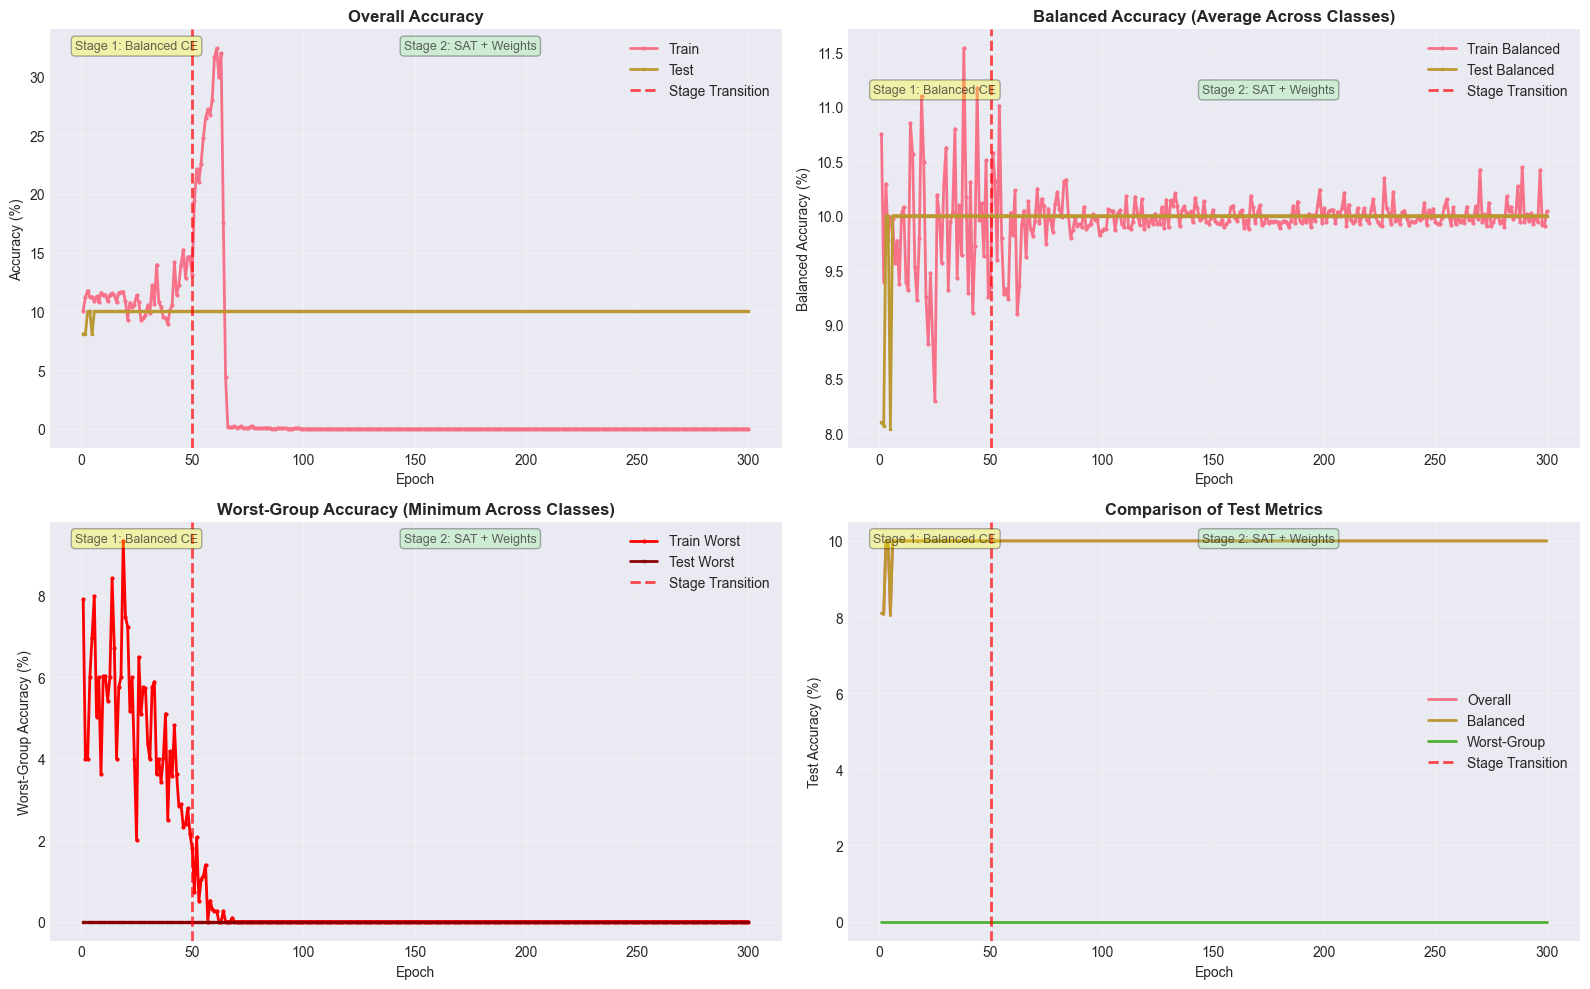

✅ Training curves saved to ./checkpoints/cclsc_longtailed_ir100/training_curves.png


In [14]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Mark stage transition
stage_line = config.stage1_epochs

# 1. Overall accuracy
ax = axes[0, 0]
ax.plot(history['epoch'], history['train_acc'], label='Train', linewidth=2, marker='o', markersize=2)
ax.plot(history['epoch'], history['test_acc'], label='Test', linewidth=2, marker='s', markersize=2)
ax.axvline(x=stage_line, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Stage Transition')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Overall Accuracy', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Balanced accuracy
ax = axes[0, 1]
ax.plot(history['epoch'], history['train_balanced_acc'], label='Train Balanced', linewidth=2, marker='o', markersize=2)
ax.plot(history['epoch'], history['test_balanced_acc'], label='Test Balanced', linewidth=2, marker='s', markersize=2)
ax.axvline(x=stage_line, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Stage Transition')
ax.set_xlabel('Epoch')
ax.set_ylabel('Balanced Accuracy (%)')
ax.set_title('Balanced Accuracy (Average Across Classes)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Worst-group accuracy
ax = axes[1, 0]
ax.plot(history['epoch'], history['train_worst_acc'], label='Train Worst', linewidth=2, marker='o', markersize=2, color='red')
ax.plot(history['epoch'], history['test_worst_acc'], label='Test Worst', linewidth=2, marker='s', markersize=2, color='darkred')
ax.axvline(x=stage_line, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Stage Transition')
ax.set_xlabel('Epoch')
ax.set_ylabel('Worst-Group Accuracy (%)')
ax.set_title('Worst-Group Accuracy (Minimum Across Classes)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. All metrics together
ax = axes[1, 1]
ax.plot(history['epoch'], history['test_acc'], label='Overall', linewidth=2)
ax.plot(history['epoch'], history['test_balanced_acc'], label='Balanced', linewidth=2)
ax.plot(history['epoch'], history['test_worst_acc'], label='Worst-Group', linewidth=2)
ax.axvline(x=stage_line, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Stage Transition')
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Comparison of Test Metrics', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Add text annotations for stages
for ax in axes.flat:
    ax.text(stage_line/2, ax.get_ylim()[1]*0.95, 'Stage 1: Balanced CE', 
           fontsize=9, alpha=0.7, ha='center',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    ax.text((stage_line + config.epochs)/2, ax.get_ylim()[1]*0.95, 'Stage 2: SAT + Weights', 
           fontsize=9, alpha=0.7, ha='center',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.3))

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'training_curves.png'), dpi=150)
plt.show()

print(f"✅ Training curves saved to {config.save_dir}/training_curves.png")

## 9. Per-Class Performance Analysis


Final Per-Class Performance (SAT + Class-Balanced Loss):


,Class,Train Samples,Test Accuracy (%),Test Error (%)
0,airplane,5000,100.0,0.0
1,automobile,2997,0.0,100.0
2,bird,1796,0.0,100.0
3,cat,1077,0.0,100.0
4,deer,645,0.0,100.0
5,dog,387,0.0,100.0
6,frog,232,0.0,100.0
7,horse,139,0.0,100.0
8,ship,83,0.0,100.0
9,truck,50,0.0,100.0


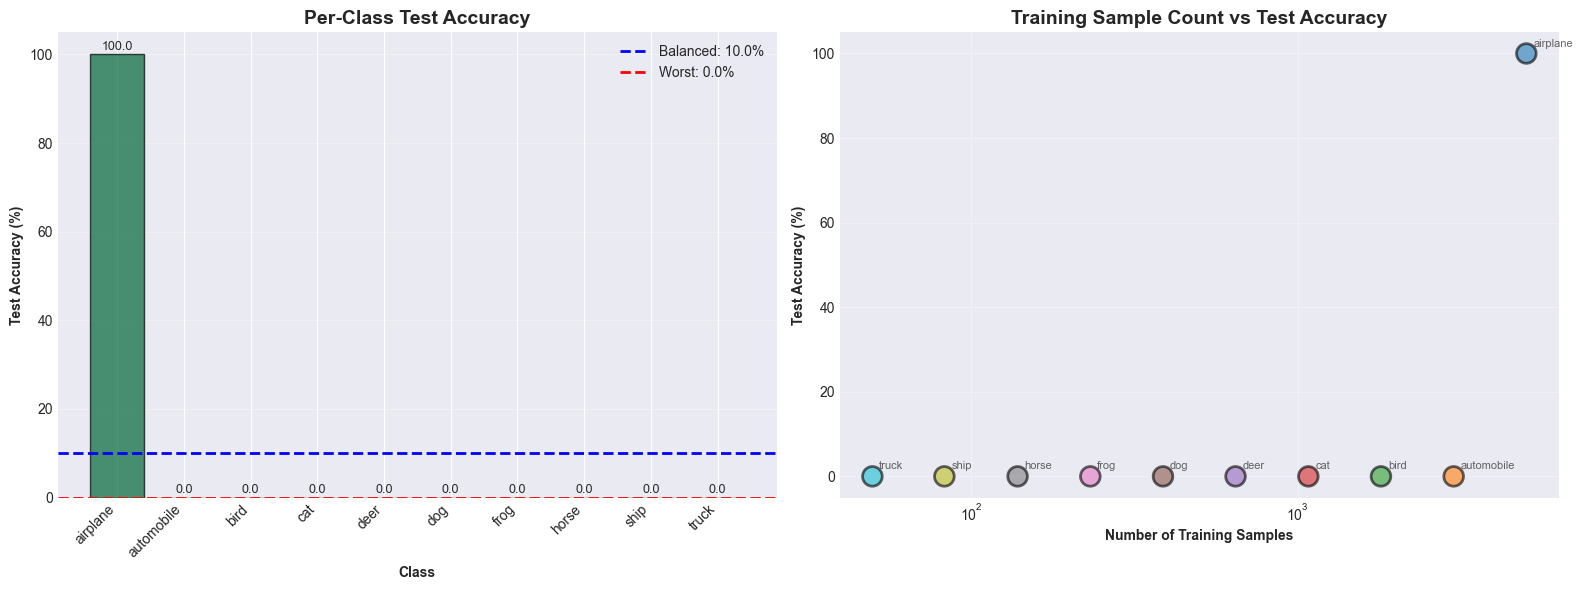


✅ Per-class analysis saved to ./checkpoints/cclsc_longtailed_ir100/per_class_performance.png


In [15]:
# Analyze final per-class performance
final_class_acc = history['test_class_acc'][-1]
train_dist = trainset.get_class_distribution()

# Create DataFrame
df_class_perf = pd.DataFrame({
    'Class': class_names,
    'Train Samples': [train_dist[i] for i in range(num_classes)],
    'Test Accuracy (%)': final_class_acc,
    'Test Error (%)': [100 - acc for acc in final_class_acc]
})

print("\n" + "="*80)
print("Final Per-Class Performance (SAT + Class-Balanced Loss):")
print("="*80)
display(df_class_perf)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Accuracy by class
ax = axes[0]
colors = plt.cm.RdYlGn(np.array(final_class_acc) / 100)
bars = ax.bar(range(num_classes), final_class_acc, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Class', fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontweight='bold')
ax.set_title('Per-Class Test Accuracy', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.axhline(y=np.mean(final_class_acc), color='blue', linestyle='--', linewidth=2, label=f'Balanced: {np.mean(final_class_acc):.1f}%')
ax.axhline(y=np.min(final_class_acc), color='red', linestyle='--', linewidth=2, label=f'Worst: {np.min(final_class_acc):.1f}%')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, acc in enumerate(final_class_acc):
    ax.text(i, acc + 1, f'{acc:.1f}', ha='center', fontsize=9)

# 2. Training samples vs accuracy
ax = axes[1]
train_samples = [train_dist[i] for i in range(num_classes)]
scatter = ax.scatter(train_samples, final_class_acc, s=200, alpha=0.6, c=range(num_classes), 
                     cmap='tab10', edgecolors='black', linewidth=2)
ax.set_xlabel('Number of Training Samples', fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontweight='bold')
ax.set_title('Training Sample Count vs Test Accuracy', fontweight='bold', fontsize=14)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Add class labels
for i, name in enumerate(class_names):
    ax.annotate(name, (train_samples[i], final_class_acc[i]), 
                fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'per_class_performance.png'), dpi=150)
plt.show()

print(f"\n✅ Per-class analysis saved to {config.save_dir}/per_class_performance.png")

## 10. Coverage-Based Analysis: Balanced and Worst-Group Error


Coverage-Based Error Analysis:


,coverage,overall_error,balanced_error,worst_group_error
0,100.0,90.000000,90.0,100.0
1,99.0,90.040404,90.0,100.0
2,98.0,90.020408,90.0,100.0
3,97.0,90.030928,90.0,100.0
4,95.0,90.042105,90.0,100.0
5,90.0,90.033333,90.0,100.0
6,85.0,90.082353,90.0,100.0
7,80.0,90.012500,90.0,100.0
8,75.0,90.000000,90.0,100.0
9,70.0,89.942857,90.0,100.0


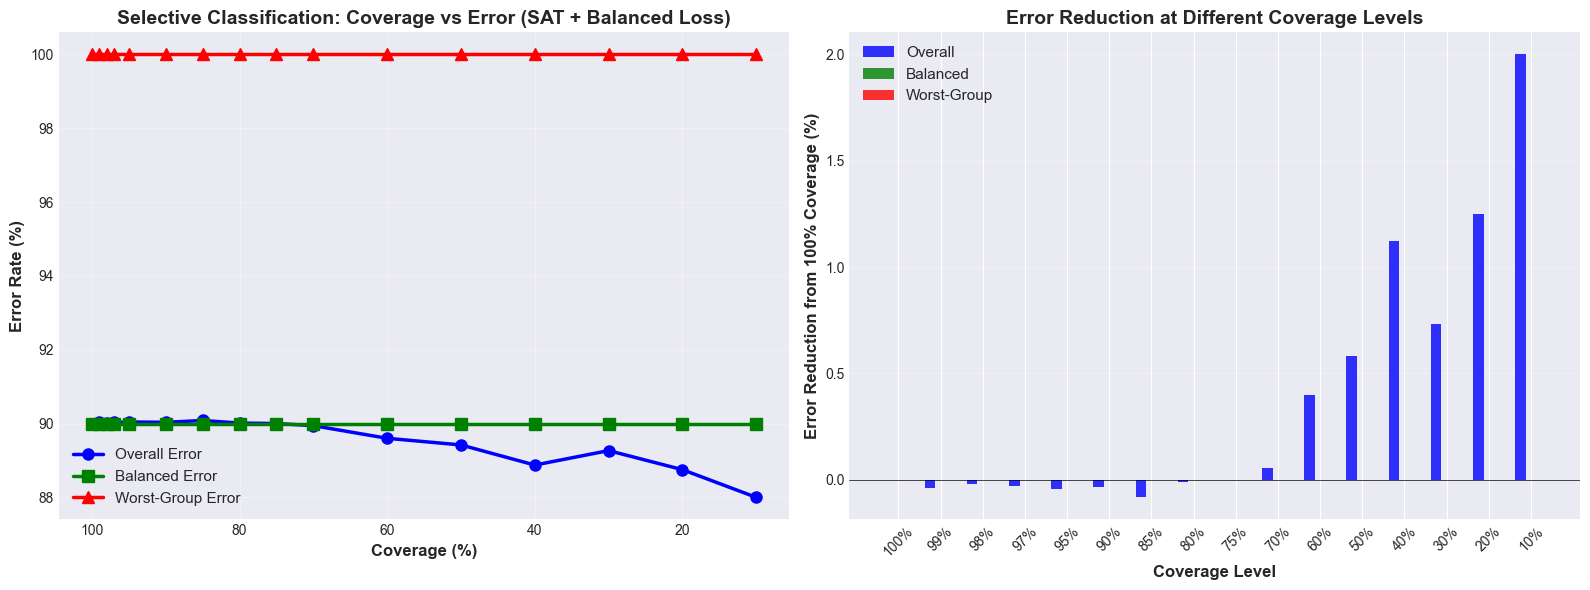


✅ Coverage analysis saved to ./checkpoints/cclsc_longtailed_ir100/coverage_analysis.png


In [16]:
# Extract final coverage results
final_coverage = history['coverage_results'][-1]

# Create DataFrame
df_coverage = pd.DataFrame(final_coverage)

print("\n" + "="*80)
print("Coverage-Based Error Analysis:")
print("="*80)
display(df_coverage[['coverage', 'overall_error', 'balanced_error', 'worst_group_error']])

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Coverage vs Error curves
ax = axes[0]
ax.plot(df_coverage['coverage'], df_coverage['overall_error'], 
        marker='o', markersize=8, linewidth=2.5, label='Overall Error', color='blue')
ax.plot(df_coverage['coverage'], df_coverage['balanced_error'], 
        marker='s', markersize=8, linewidth=2.5, label='Balanced Error', color='green')
ax.plot(df_coverage['coverage'], df_coverage['worst_group_error'], 
        marker='^', markersize=8, linewidth=2.5, label='Worst-Group Error', color='red')
ax.set_xlabel('Coverage (%)', fontweight='bold', fontsize=12)
ax.set_ylabel('Error Rate (%)', fontweight='bold', fontsize=12)
ax.set_title('Selective Classification: Coverage vs Error (SAT + Balanced Loss)', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

# 2. Error reduction comparison
ax = axes[1]
overall_reduction = df_coverage['overall_error'].iloc[0] - df_coverage['overall_error']
balanced_reduction = df_coverage['balanced_error'].iloc[0] - df_coverage['balanced_error']
worst_reduction = df_coverage['worst_group_error'].iloc[0] - df_coverage['worst_group_error']

x = np.arange(len(df_coverage))
width = 0.25

ax.bar(x - width, overall_reduction, width, label='Overall', alpha=0.8, color='blue')
ax.bar(x, balanced_reduction, width, label='Balanced', alpha=0.8, color='green')
ax.bar(x + width, worst_reduction, width, label='Worst-Group', alpha=0.8, color='red')

ax.set_xlabel('Coverage Level', fontweight='bold', fontsize=12)
ax.set_ylabel('Error Reduction from 100% Coverage (%)', fontweight='bold', fontsize=12)
ax.set_title('Error Reduction at Different Coverage Levels', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f"{int(c)}%" for c in df_coverage['coverage']], rotation=45)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'coverage_analysis.png'), dpi=150)
plt.show()

print(f"\n✅ Coverage analysis saved to {config.save_dir}/coverage_analysis.png")

## 11. AURC Calculation: Balanced and Worst-Group Risk


AURC (Area Under Risk-Coverage Curve) - Lower is Better
AURC (Overall):     0.804958  ✅
AURC (Balanced):    0.810000  ✅ [Balanced risk metric]
AURC (Worst-Group): 0.900000  ✅ [Worst-case risk metric]


/tmp/ipykernel_600866/1605444340.py:69: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_600866/1605444340.py:70: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(os.path.join(config.save_dir, 'aurc_analysis.png'), dpi=150)
/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


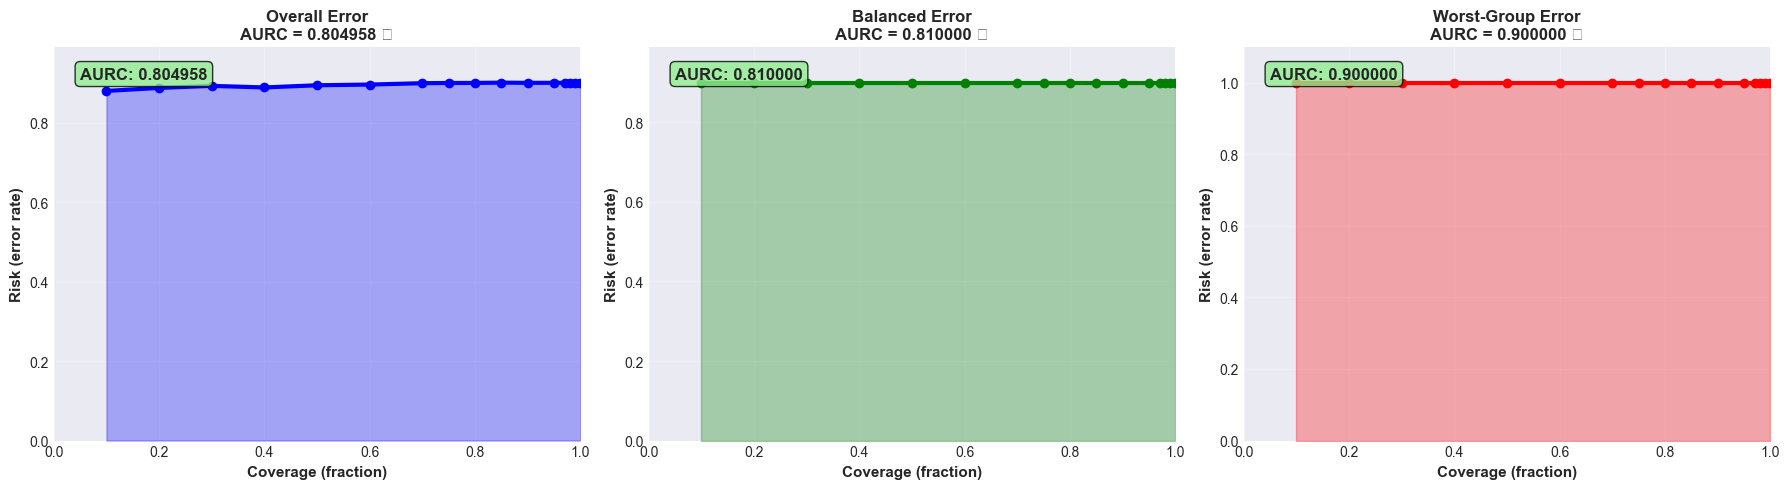


✅ AURC analysis saved to ./checkpoints/cclsc_longtailed_ir100/aurc_analysis.png


In [17]:
def calculate_aurc(coverages, errors):
    """
    Calculate Area Under the Risk-Coverage curve
    AURC = integral of error rate over coverage
    Lower is better
    """
    # Sort by coverage (ASCENDING)
    sorted_indices = np.argsort(coverages)
    sorted_cov = np.array(coverages)[sorted_indices]
    sorted_err = np.array(errors)[sorted_indices]
    
    # Normalize coverage to [0, 1]
    cov_normalized = sorted_cov / 100.0
    err_normalized = sorted_err / 100.0
    
    # Integrate from LOW to HIGH coverage
    aurc = np.trapz(err_normalized, cov_normalized)
    return aurc

# Calculate AURC for different metrics
coverages = df_coverage['coverage'].values
overall_errors = df_coverage['overall_error'].values
balanced_errors = df_coverage['balanced_error'].values
worst_errors = df_coverage['worst_group_error'].values

aurc_overall = calculate_aurc(coverages, overall_errors)
aurc_balanced = calculate_aurc(coverages, balanced_errors)
aurc_worst = calculate_aurc(coverages, worst_errors)

print("\n" + "="*80)
print("AURC (Area Under Risk-Coverage Curve) - Lower is Better")
print("="*80)
print(f"AURC (Overall):     {aurc_overall:.6f}  ✅")
print(f"AURC (Balanced):    {aurc_balanced:.6f}  ✅ [Balanced risk metric]")
print(f"AURC (Worst-Group): {aurc_worst:.6f}  ✅ [Worst-case risk metric]")
print("="*80)

# Visualize AURC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (ax, errors, title, color, aurc) in enumerate([
    (axes[0], overall_errors, 'Overall Error', 'blue', aurc_overall),
    (axes[1], balanced_errors, 'Balanced Error', 'green', aurc_balanced),
    (axes[2], worst_errors, 'Worst-Group Error', 'red', aurc_worst)
]):
    # Sort by coverage (ASCENDING)
    sorted_idx = np.argsort(coverages)
    cov_norm = coverages[sorted_idx] / 100.0
    err_norm = errors[sorted_idx] / 100.0
    
    # Plot curve
    ax.plot(cov_norm, err_norm, linewidth=3, color=color, marker='o', markersize=6)
    
    # Fill area under curve
    ax.fill_between(cov_norm, 0, err_norm, alpha=0.3, color=color)
    
    ax.set_xlabel('Coverage (fraction)', fontweight='bold', fontsize=11)
    ax.set_ylabel('Risk (error rate)', fontweight='bold', fontsize=11)
    ax.set_title(f'{title}\nAURC = {aurc:.6f} ✅', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, max(err_norm) * 1.1])
    
    # Add text box with AURC value
    ax.text(0.05, 0.95, f'AURC: {aurc:.6f}', transform=ax.transAxes,
            verticalalignment='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'aurc_analysis.png'), dpi=150)
plt.show()

print(f"\n✅ AURC analysis saved to {config.save_dir}/aurc_analysis.png")

## 12. Summary Report

In [18]:
# Generate comprehensive summary
print("\n" + "="*100)
print(f"SAT WITH CLASS-BALANCED LOSS - FINAL REPORT (IR={config.imbalance_ratio})")
print("="*100)

print("\n1. OVERALL PERFORMANCE:")
print("-" * 100)
print(f"Final Test Accuracy (Overall):     {history['test_acc'][-1]:.2f}%")
print(f"Final Test Accuracy (Balanced):    {history['test_balanced_acc'][-1]:.2f}%")
print(f"Final Test Accuracy (Worst-Group): {history['test_worst_acc'][-1]:.2f}%")
print(f"\nBest Balanced Accuracy:             {best_balanced_acc:.2f}%")
print(f"Best Worst-Group Accuracy:          {best_worst_acc:.2f}%")

print("\n2. PER-CLASS ACCURACY:")
print("-" * 100)
for i, (name, acc, samples) in enumerate(zip(class_names, final_class_acc, [train_dist[i] for i in range(num_classes)])):
    status = "✅" if acc > 50 else "⚠️ " if acc > 30 else "❌"
    print(f"Class {i} ({name:12s}): {acc:6.2f}%  (train samples: {samples:5d}) {status}")

print("\n3. COVERAGE-BASED ANALYSIS (Key Coverage Levels):")
print("-" * 100)
print(f"{'Coverage':<10} | {'Overall Err':<12} | {'Balanced Err':<13} | {'Worst Err':<10} | {'Bal Reduction':<14} | {'Worst Reduction':<15}")
print("-" * 100)

for cov in [100, 99, 95, 90, 85, 80, 75, 70]:
    row = df_coverage[df_coverage['coverage'] == cov]
    if len(row) > 0:
        overall_err = row['overall_error'].values[0]
        bal_err = row['balanced_error'].values[0]
        worst_err = row['worst_group_error'].values[0]
        
        bal_reduction = df_coverage['balanced_error'].iloc[0] - bal_err
        worst_reduction = df_coverage['worst_group_error'].iloc[0] - worst_err
        
        print(f"{cov:<10.0f} | {overall_err:<12.2f} | {bal_err:<13.2f} | {worst_err:<10.2f} | "
              f"{bal_reduction:<14.2f} | {worst_reduction:<15.2f}")

print("\n4. AURC (Area Under Risk-Coverage Curve):")
print("-" * 100)
print(f"AURC (Overall):     {aurc_overall:.6f}")
print(f"AURC (Balanced):    {aurc_balanced:.6f}  [Balanced risk metric]")
print(f"AURC (Worst-Group): {aurc_worst:.6f}  [Worst-case risk metric]")

print("\n5. COMPARISON WITH BASELINE SAT:")
print("-" * 100)
baseline_balanced = 62.48  # From previous baseline run
baseline_worst = 0.0  # From previous baseline
baseline_aurc_balanced = 0.398418

improvement_balanced = history['test_balanced_acc'][-1] - baseline_balanced
improvement_worst = history['test_worst_acc'][-1] - baseline_worst
improvement_aurc = baseline_aurc_balanced - aurc_balanced

print(f"Baseline Balanced Acc:       {baseline_balanced:.2f}%")
print(f"New Balanced Acc:            {history['test_balanced_acc'][-1]:.2f}%")
print(f"Improvement:                 {improvement_balanced:+.2f}% {'✅' if improvement_balanced > 0 else '❌'}")

print(f"\nBaseline Worst Acc:          {baseline_worst:.2f}%")
print(f"New Worst Acc:               {history['test_worst_acc'][-1]:.2f}%")
print(f"Improvement:                 {improvement_worst:+.2f}% {'✅' if improvement_worst > 0 else '❌'}")

print(f"\nBaseline AURC (Balanced):    {baseline_aurc_balanced:.6f}")
print(f"New AURC (Balanced):         {aurc_balanced:.6f}")
print(f"Improvement:                 {improvement_aurc:+.6f} {'✅' if improvement_aurc > 0 else '❌'}")

print("\n" + "="*100)

# Save report to file
report_path = os.path.join(config.save_dir, 'summary_report.txt')
with open(report_path, 'w') as f:
    f.write(f"SAT WITH CLASS-BALANCED LOSS - SUMMARY REPORT (IR={config.imbalance_ratio})\n")
    f.write("="*100 + "\n\n")
    f.write(f"APPROACH: SAT + Class-Balanced Loss Weighting (Two-Stage Training)\n\n")
    f.write(f"Stage 1 (0-{config.stage1_epochs}): Balanced Cross-Entropy\n")
    f.write(f"Stage 2 ({config.stage1_epochs}-{config.epochs}): SAT + Class-Balanced Loss\n\n")
    f.write(f"Final Test Accuracy (Overall):     {history['test_acc'][-1]:.2f}%\n")
    f.write(f"Final Test Accuracy (Balanced):    {history['test_balanced_acc'][-1]:.2f}%\n")
    f.write(f"Final Test Accuracy (Worst-Group): {history['test_worst_acc'][-1]:.2f}%\n\n")
    f.write(f"AURC (Overall):     {aurc_overall:.6f}\n")
    f.write(f"AURC (Balanced):    {aurc_balanced:.6f}\n")
    f.write(f"AURC (Worst-Group): {aurc_worst:.6f}\n\n")
    f.write(f"Improvement vs Baseline SAT:\n")
    f.write(f"  Balanced Acc: {improvement_balanced:+.2f}%\n")
    f.write(f"  Worst Acc: {improvement_worst:+.2f}%\n")
    f.write(f"  AURC (Balanced): {improvement_aurc:+.6f}\n")

print(f"\n✅ Summary report saved to: {report_path}")

# Save coverage results to CSV
csv_path = os.path.join(config.save_dir, 'coverage_results.csv')
df_coverage[['coverage', 'overall_error', 'balanced_error', 'worst_group_error']].to_csv(csv_path, index=False)
print(f"✅ Coverage results saved to: {csv_path}")

print("\n✅ Analysis complete!")


SAT WITH CLASS-BALANCED LOSS - FINAL REPORT (IR=100)

1. OVERALL PERFORMANCE:
----------------------------------------------------------------------------------------------------
Final Test Accuracy (Overall):     10.00%
Final Test Accuracy (Balanced):    10.00%
Final Test Accuracy (Worst-Group): 0.00%

Best Balanced Accuracy:             10.00%
Best Worst-Group Accuracy:          0.00%

2. PER-CLASS ACCURACY:
----------------------------------------------------------------------------------------------------
Class 0 (airplane    ): 100.00%  (train samples:  5000) ✅
Class 1 (automobile  ):   0.00%  (train samples:  2997) ❌
Class 2 (bird        ):   0.00%  (train samples:  1796) ❌
Class 3 (cat         ):   0.00%  (train samples:  1077) ❌
Class 4 (deer        ):   0.00%  (train samples:   645) ❌
Class 5 (dog         ):   0.00%  (train samples:   387) ❌
Class 6 (frog        ):   0.00%  (train samples:   232) ❌
Class 7 (horse       ):   0.00%  (train samples:   139) ❌
Class 8 (ship       